# Machine Learning: Dimensionality Reduction Tutorial

This notebook covers key dimensionality reduction techniques for visualization and preprocessing:
- **PCA (Principal Component Analysis)** — Linear baseline
- **MDS (Multidimensional Scaling)** — Distance-preserving
- **t-SNE** — Local structure preservation
- **UMAP** — Local + global structure preservation

All visualizations use **matplotlib only**.

**Note:** For UMAP, install via: `pip install umap-learn`


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import load_digits, make_swiss_roll, make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# UMAP import (install: pip install umap-learn)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not installed. Install with: pip install umap-learn")

np.random.seed(42)


UMAP not installed. Install with: pip install umap-learn


# 0. The Dataset: Handwritten Digits

We use sklearn's built-in **digits dataset** (8x8 images, 64 features, 10 classes).
It is small enough to run quickly but high-dimensional enough to demonstrate
the value of dimensionality reduction.


Shape of data: (1797, 64)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


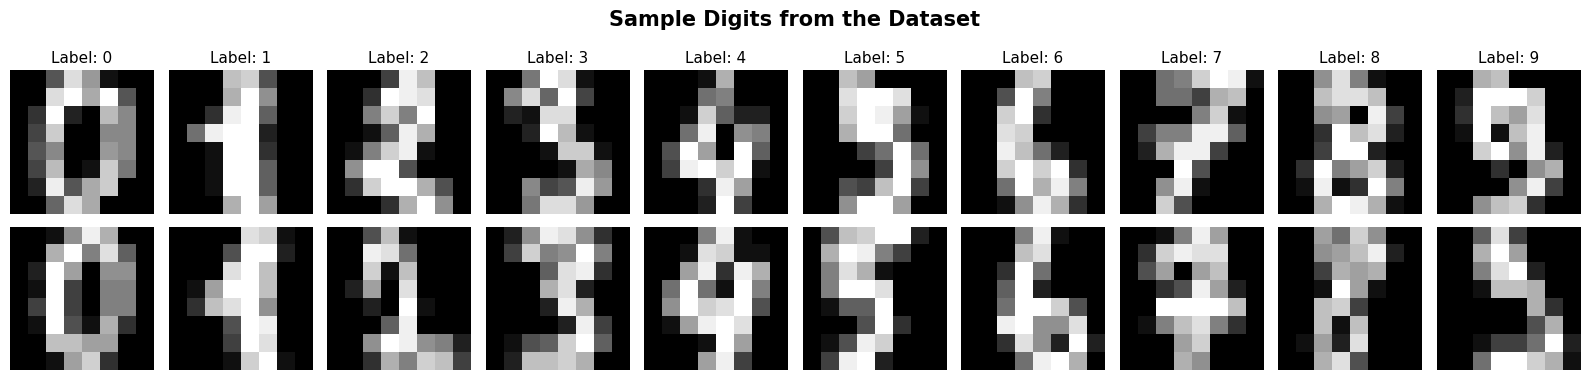

In [3]:
# Load digits dataset
digits = load_digits()
X_digits = digits.data
y_digits = digits.target
images = digits.images

print("Shape of data:", X_digits.shape)
print("Number of classes:", len(np.unique(y_digits)))
print("Classes:", np.unique(y_digits))

# Visualize sample images
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i in range(10):
    # First occurrence of each digit
    idx = np.where(y_digits == i)[0][0]
    axes[0, i].imshow(images[idx], cmap="gray")
    axes[0, i].set_title("Label: " + str(i), fontsize=11)
    axes[0, i].axis("off")
    
    # Another random sample
    idx2 = np.where(y_digits == i)[0][1]
    axes[1, i].imshow(images[idx2], cmap="gray")
    axes[1, i].axis("off")

plt.suptitle("Sample Digits from the Dataset", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


# 1. PCA (Principal Component Analysis)

## Theory

**PCA** is a **linear** technique that projects data onto a lower-dimensional subspace
while maximizing the variance captured.

### How it works:
1. Center the data (subtract mean)
2. Compute the covariance matrix
3. Find eigenvectors (principal components) and eigenvalues
4. Project data onto the top-k eigenvectors

### Pros:
- Fast and deterministic
- Removes correlated features
- Great for preprocessing before other algorithms

### Cons:
- Only captures **linear** relationships
- Sensitive to feature scaling
- PCA components are not always interpretable

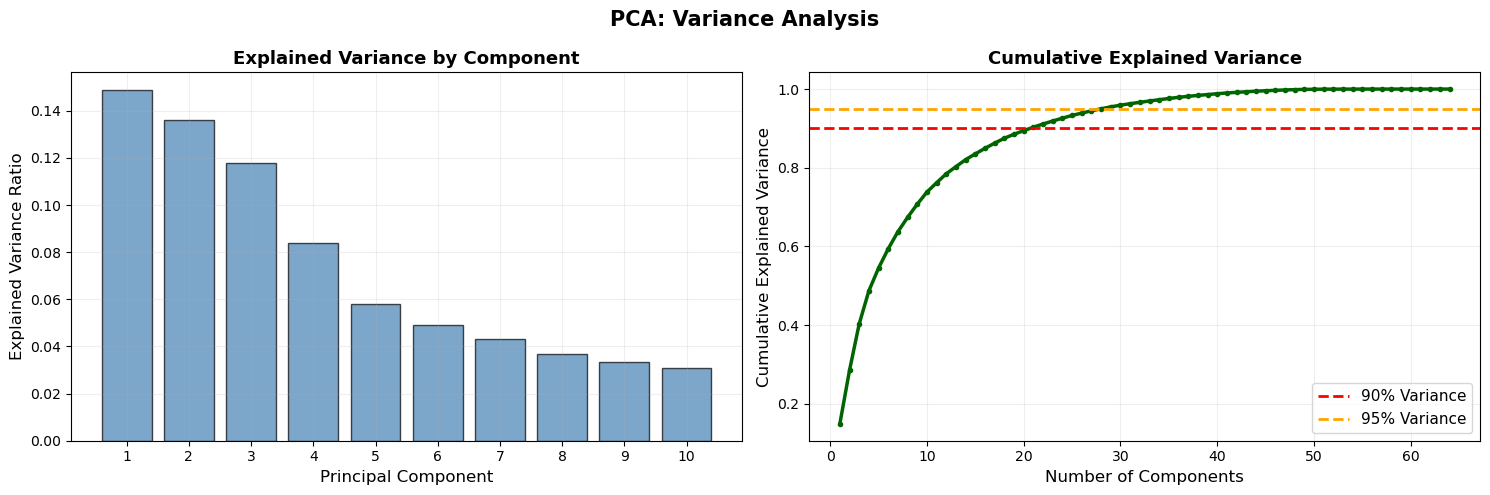

In [4]:
# Apply PCA
pca = PCA()
X_pca_full = pca.fit_transform(X_digits)

# Explained Variance Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Individual variance
ax1.bar(range(1, 11), pca.explained_variance_ratio_[:10], alpha=0.7, color="steelblue", edgecolor="k")
ax1.set_xlabel("Principal Component", fontsize=12)
ax1.set_ylabel("Explained Variance Ratio", fontsize=12)
ax1.set_title("Explained Variance by Component", fontsize=13, fontweight="bold")
ax1.set_xticks(range(1, 11))
ax1.grid(True, alpha=0.2)

# Cumulative variance
cumsum = np.cumsum(pca.explained_variance_ratio_)
ax2.plot(range(1, 65), cumsum, "b-", linewidth=2.5, marker="o", markersize=3, color="darkgreen")
ax2.axhline(y=0.90, color="red", linestyle="--", linewidth=2, label="90% Variance")
ax2.axhline(y=0.95, color="orange", linestyle="--", linewidth=2, label="95% Variance")
ax2.set_xlabel("Number of Components", fontsize=12)
ax2.set_ylabel("Cumulative Explained Variance", fontsize=12)
ax2.set_title("Cumulative Explained Variance", fontsize=13, fontweight="bold")
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.2)

plt.suptitle("PCA: Variance Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


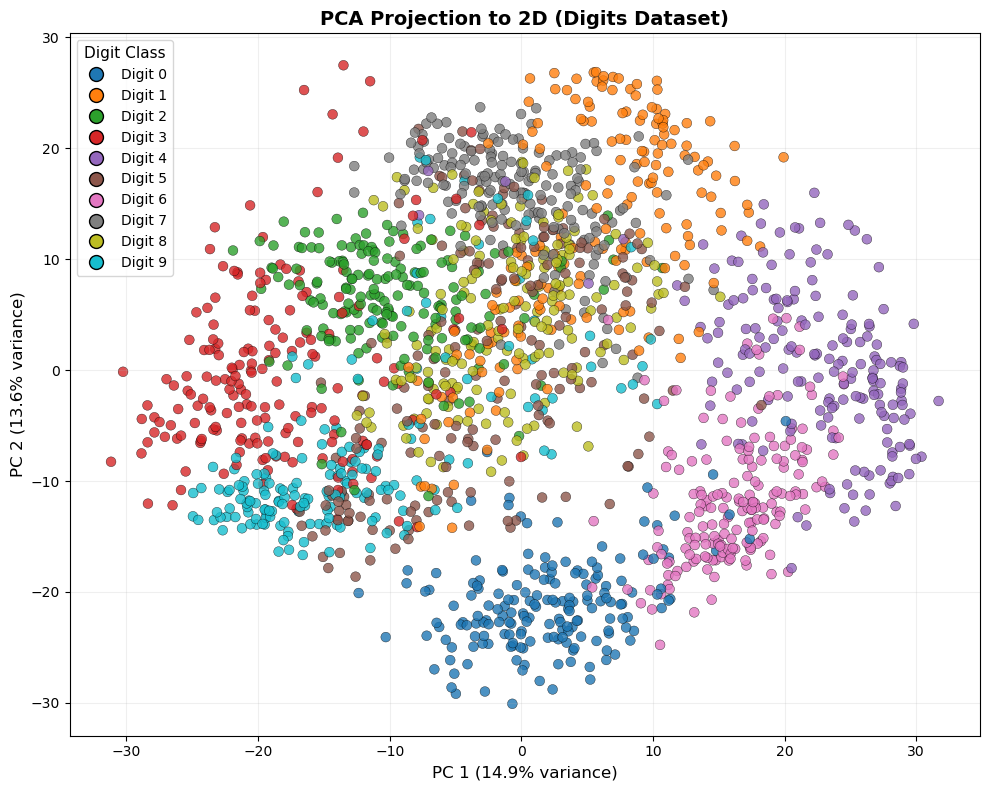

In [5]:
# PCA 2D Projection
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_digits)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_digits, cmap="tab10", s=50, alpha=0.8,
    edgecolors="k", linewidth=0.3
)
ax.set_title("PCA Projection to 2D (Digits Dataset)", fontsize=14, fontweight="bold")
ax.set_xlabel("PC 1 (" + str(round(pca_2d.explained_variance_ratio_[0]*100, 1)) + "% variance)", fontsize=12)
ax.set_ylabel("PC 2 (" + str(round(pca_2d.explained_variance_ratio_[1]*100, 1)) + "% variance)", fontsize=12)

# Legend
handles = []
for i in range(10):
    handles.append(plt.Line2D([0], [0], marker="o", color="w", 
                              markerfacecolor=plt.cm.tab10(i), markersize=10, 
                              markeredgecolor="k", label="Digit " + str(i)))
ax.legend(handles=handles, loc="best", fontsize=10, title="Digit Class", title_fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


# 2. MDS (Multidimensional Scaling)

## Theory

**MDS** seeks a low-dimensional representation of the data such that the **pairwise distances**
between points in the low-D space match the original high-D distances as closely as possible.

### Types:
- **Metric MDS**: Preserves actual distance values
- **Non-Metric MDS**: Preserves only the *rank order* of distances

### Pros:
- Preserves global structure (distances)
- No assumption of linearity
- Works with any distance metric

### Cons:
- Computationally expensive: O(n^2) to O(n^3)
- Struggles with very large datasets
- The "curse of dimensionality" can distort high-D distances

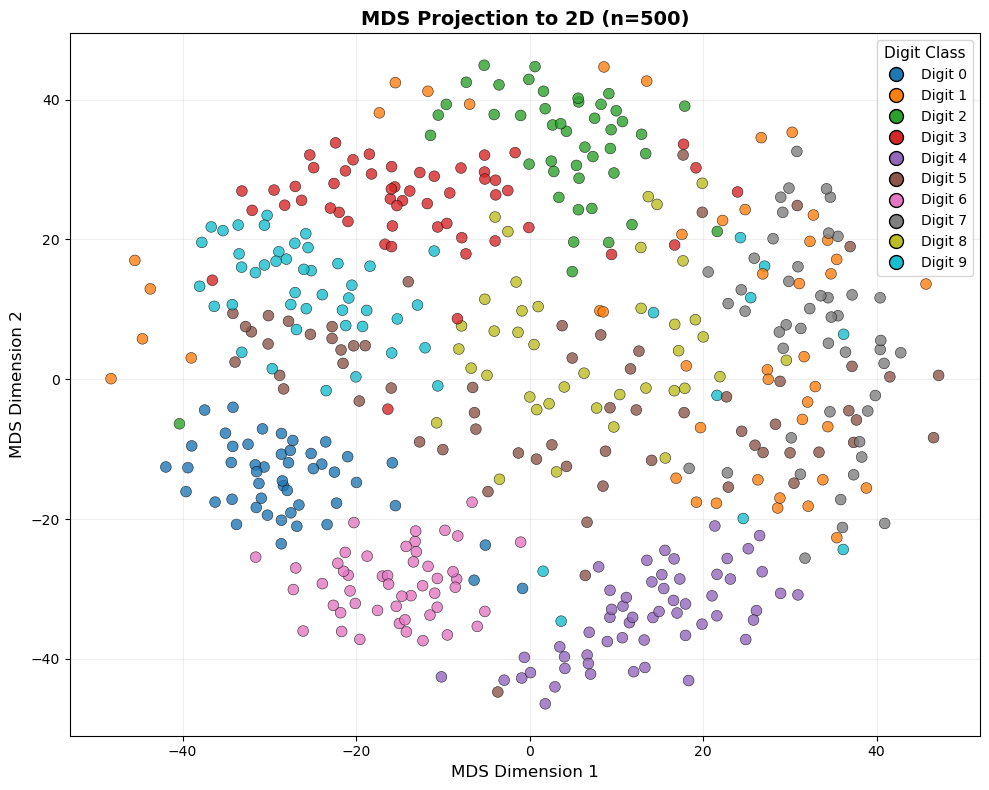

In [6]:
# MDS on a subset for speed (MDS is O(n^3))
n_subset = 500
indices = np.random.choice(X_digits.shape[0], n_subset, replace=False)
X_subset = X_digits[indices]
y_subset = y_digits[indices]

# Metric MDS
mds = MDS(n_components=2, random_state=42, normalized_stress=False)
X_mds = mds.fit_transform(X_subset)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_mds[:, 0], X_mds[:, 1],
    c=y_subset, cmap="tab10", s=60, alpha=0.8,
    edgecolors="k", linewidth=0.4
)
ax.set_title("MDS Projection to 2D (n=" + str(n_subset) + ")", fontsize=14, fontweight="bold")
ax.set_xlabel("MDS Dimension 1", fontsize=12)
ax.set_ylabel("MDS Dimension 2", fontsize=12)

handles = []
for i in range(10):
    handles.append(plt.Line2D([0], [0], marker="o", color="w", 
                              markerfacecolor=plt.cm.tab10(i), markersize=10, 
                              markeredgecolor="k", label="Digit " + str(i)))
ax.legend(handles=handles, loc="best", fontsize=10, title="Digit Class", title_fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


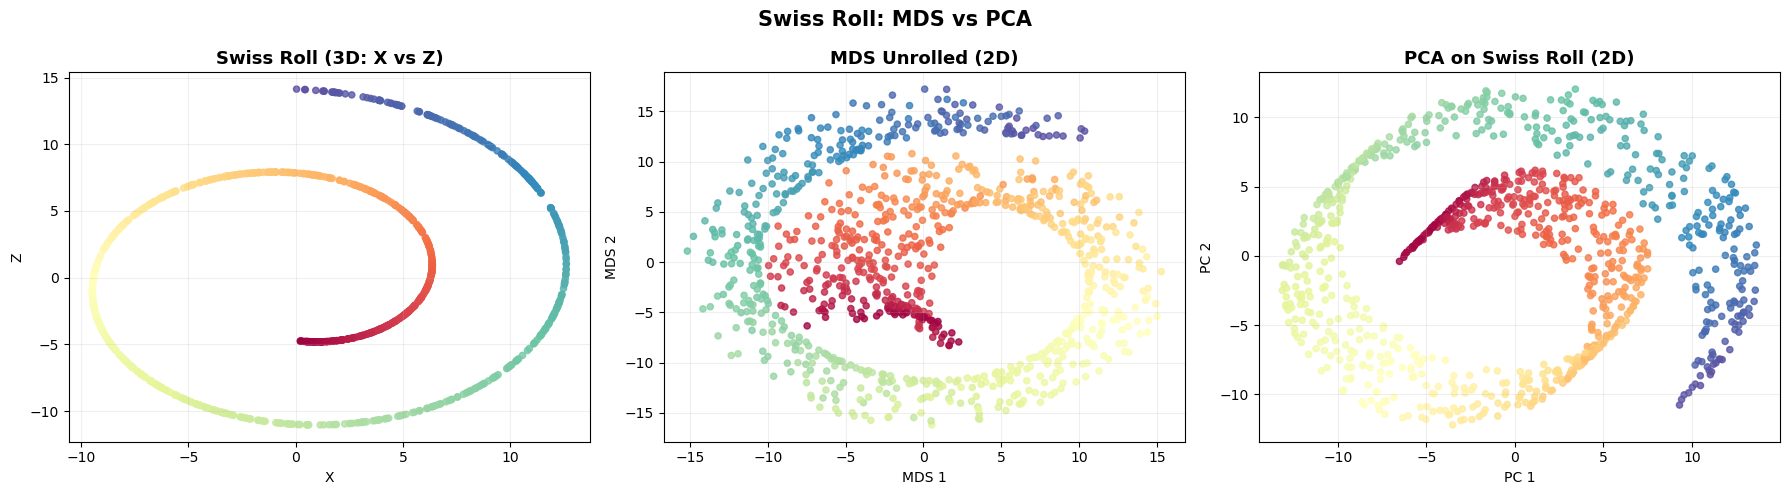

In [7]:
# MDS on Swiss Roll (unrolling a manifold)
X_swiss, color_swiss = make_swiss_roll(n_samples=1000, random_state=42)

mds_swiss = MDS(n_components=2, random_state=42, normalized_stress=False)
X_mds_swiss = mds_swiss.fit_transform(X_swiss)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3D Swiss Roll (projected)
axes[0].scatter(X_swiss[:, 0], X_swiss[:, 2], c=color_swiss, cmap="Spectral", s=20, alpha=0.8)
axes[0].set_title("Swiss Roll (3D: X vs Z)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Z")
axes[0].grid(True, alpha=0.2)

# MDS unrolled
axes[1].scatter(X_mds_swiss[:, 0], X_mds_swiss[:, 1], c=color_swiss, cmap="Spectral", s=20, alpha=0.8)
axes[1].set_title("MDS Unrolled (2D)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("MDS 1")
axes[1].set_ylabel("MDS 2")
axes[1].grid(True, alpha=0.2)

# PCA for comparison
pca_swiss = PCA(n_components=2)
X_pca_swiss = pca_swiss.fit_transform(X_swiss)
axes[2].scatter(X_pca_swiss[:, 0], X_pca_swiss[:, 1], c=color_swiss, cmap="Spectral", s=20, alpha=0.8)
axes[2].set_title("PCA on Swiss Roll (2D)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("PC 1")
axes[2].set_ylabel("PC 2")
axes[2].grid(True, alpha=0.2)

plt.suptitle("Swiss Roll: MDS vs PCA", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


# 3. t-SNE (t-Distributed Stochastic Neighbor Embedding)

## Theory

**t-SNE** converts similarities between data points to joint probabilities and tries to minimize
the Kullback-Leibler divergence between the joint probabilities of the low-dimensional embedding
and the high-dimensional data.

### Key Parameter: Perplexity
- Perplexity is a guess about the number of close neighbors each point has.
- Typical values: **5 to 50**
- Low perplexity: focuses on very local structure
- High perplexity: considers more global structure

### Pros:
- Excellent at revealing **local structure** and clusters
- Widely used for visualizing high-D data

### Cons:
- **Non-deterministic** (different runs give different results)
- Does **not** preserve global structure (distances between clusters are meaningless)
- Computationally expensive: O(n^2), slow for large datasets
- Perplexity must be tuned

Running t-SNE with perplexity=5 ...


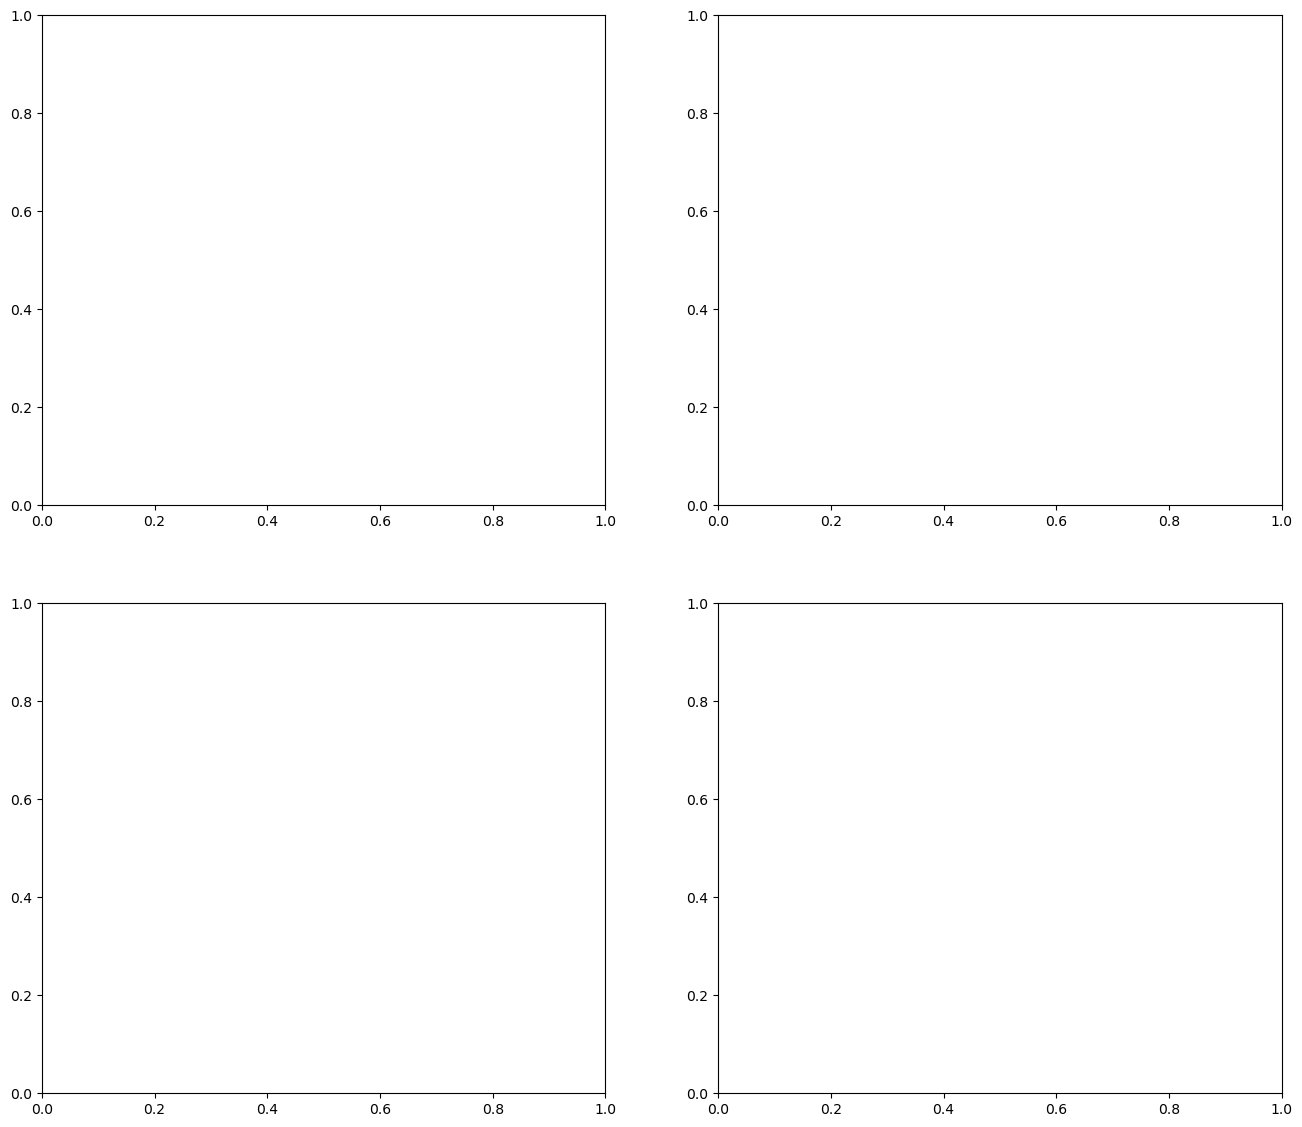

<class 'TypeError'>: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [8]:
# t-SNE with different perplexity values
perplexities = [5, 30, 50, 100]
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, perp in enumerate(perplexities):
    print("Running t-SNE with perplexity=" + str(perp) + " ...")
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, 
                init="pca", learning_rate="auto", n_iter=1000)
    X_tsne = tsne.fit_transform(X_digits)
    
    ax = axes[idx]
    scatter = ax.scatter(
        X_tsne[:, 0], X_tsne[:, 1],
        c=y_digits, cmap="tab10", s=40, alpha=0.8,
        edgecolors="k", linewidth=0.3
    )
    ax.set_title("t-SNE (perplexity=" + str(perp) + ")", fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE 1", fontsize=11)
    ax.set_ylabel("t-SNE 2", fontsize=11)
    ax.grid(True, alpha=0.2)

plt.suptitle("t-SNE: Effect of Perplexity on Digits Dataset", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


Running t-SNE with perplexity=5 ...
Running t-SNE with perplexity=30 ...
Running t-SNE with perplexity=50 ...
Running t-SNE with perplexity=100 ...


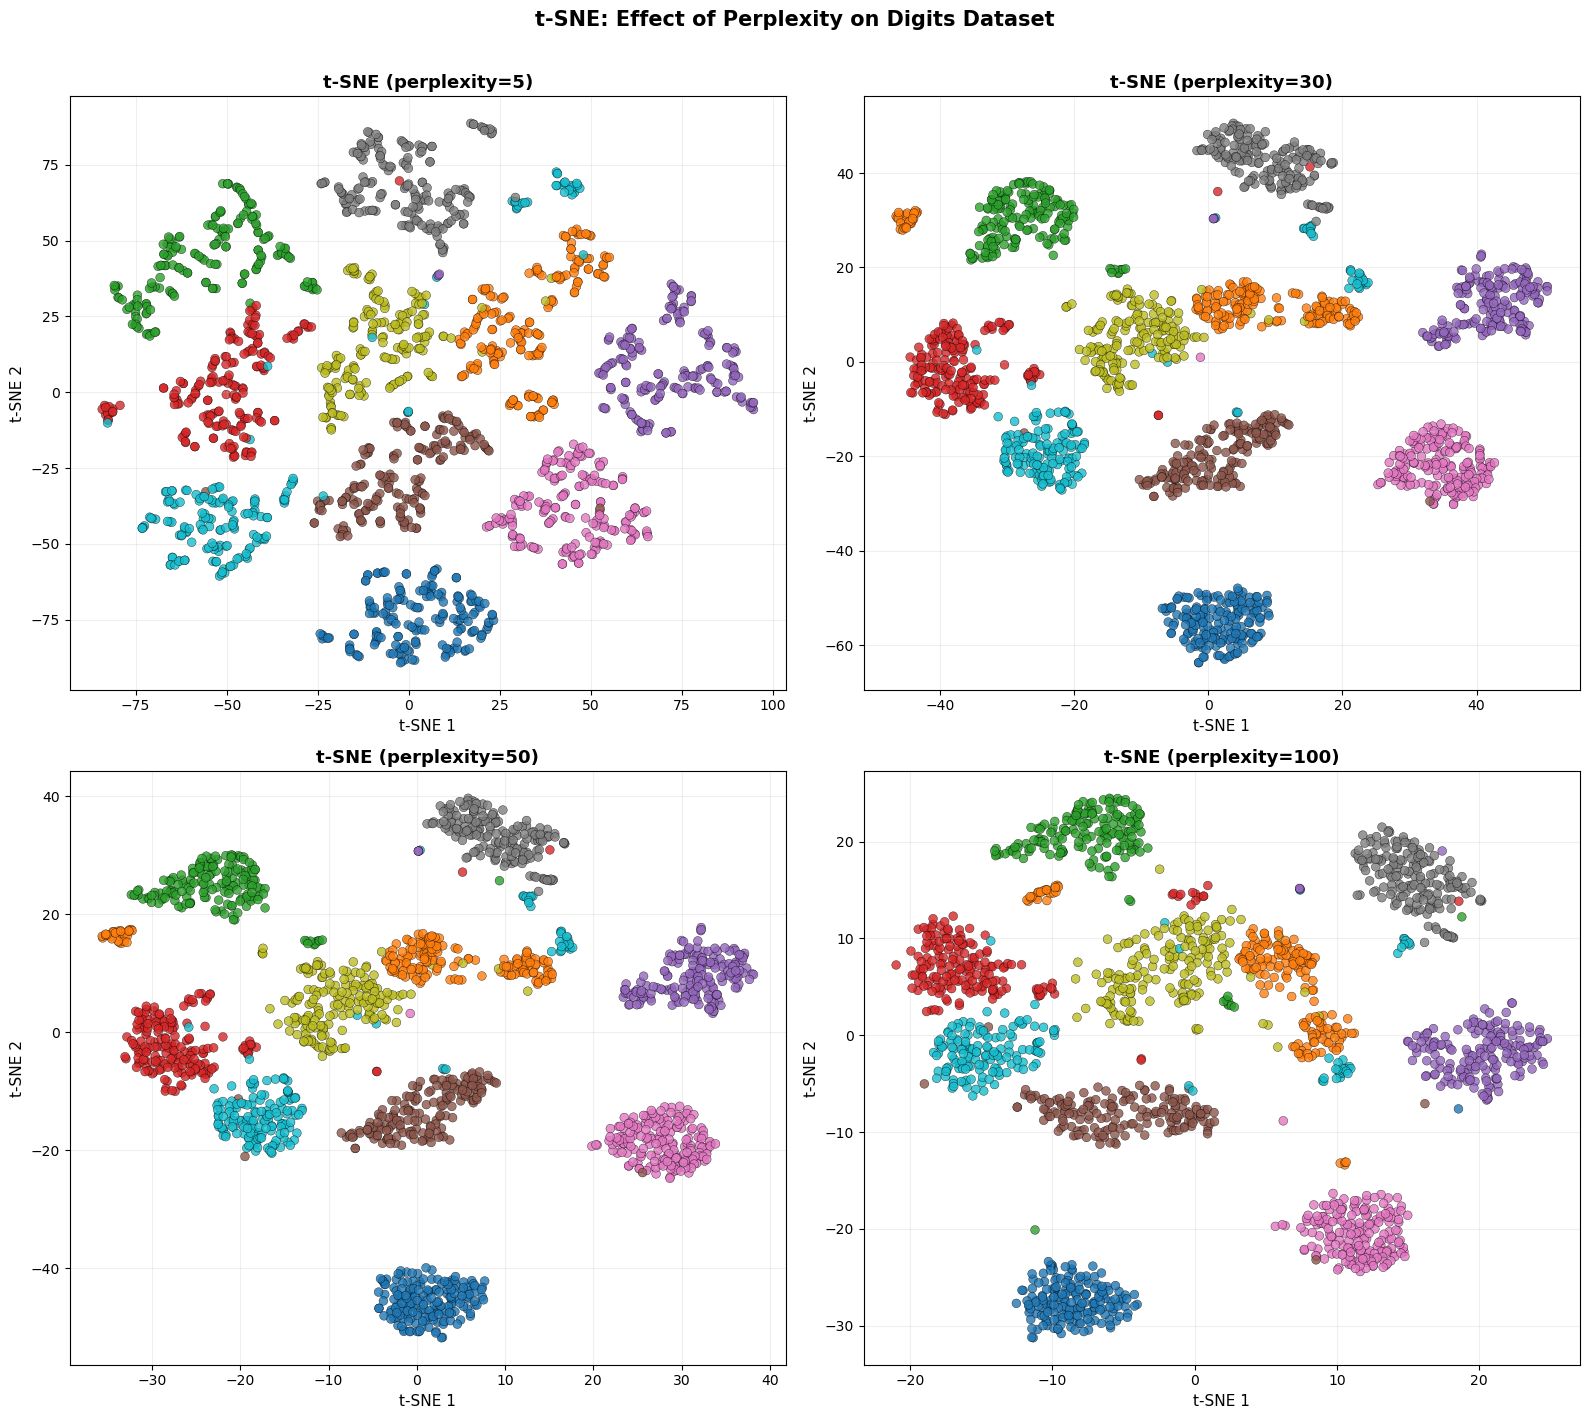

In [16]:
# t-SNE with different perplexity values
perplexities = [5, 30, 50, 100]
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, perp in enumerate(perplexities):
    print("Running t-SNE with perplexity=" + str(perp) + " ...")
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, 
                init="pca", learning_rate="auto")
    X_tsne = tsne.fit_transform(X_digits)
    
    ax = axes[idx]
    ax.scatter(
        X_tsne[:, 0], X_tsne[:, 1],
        c=y_digits, cmap="tab10", s=40, alpha=0.8,
        edgecolors="k", linewidth=0.3
    )
    ax.set_title("t-SNE (perplexity=" + str(perp) + ")", fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE 1", fontsize=11)
    ax.set_ylabel("t-SNE 2", fontsize=11)
    ax.grid(True, alpha=0.2)

plt.suptitle("t-SNE: Effect of Perplexity on Digits Dataset", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


Running t-SNE with n_iter=250 ...


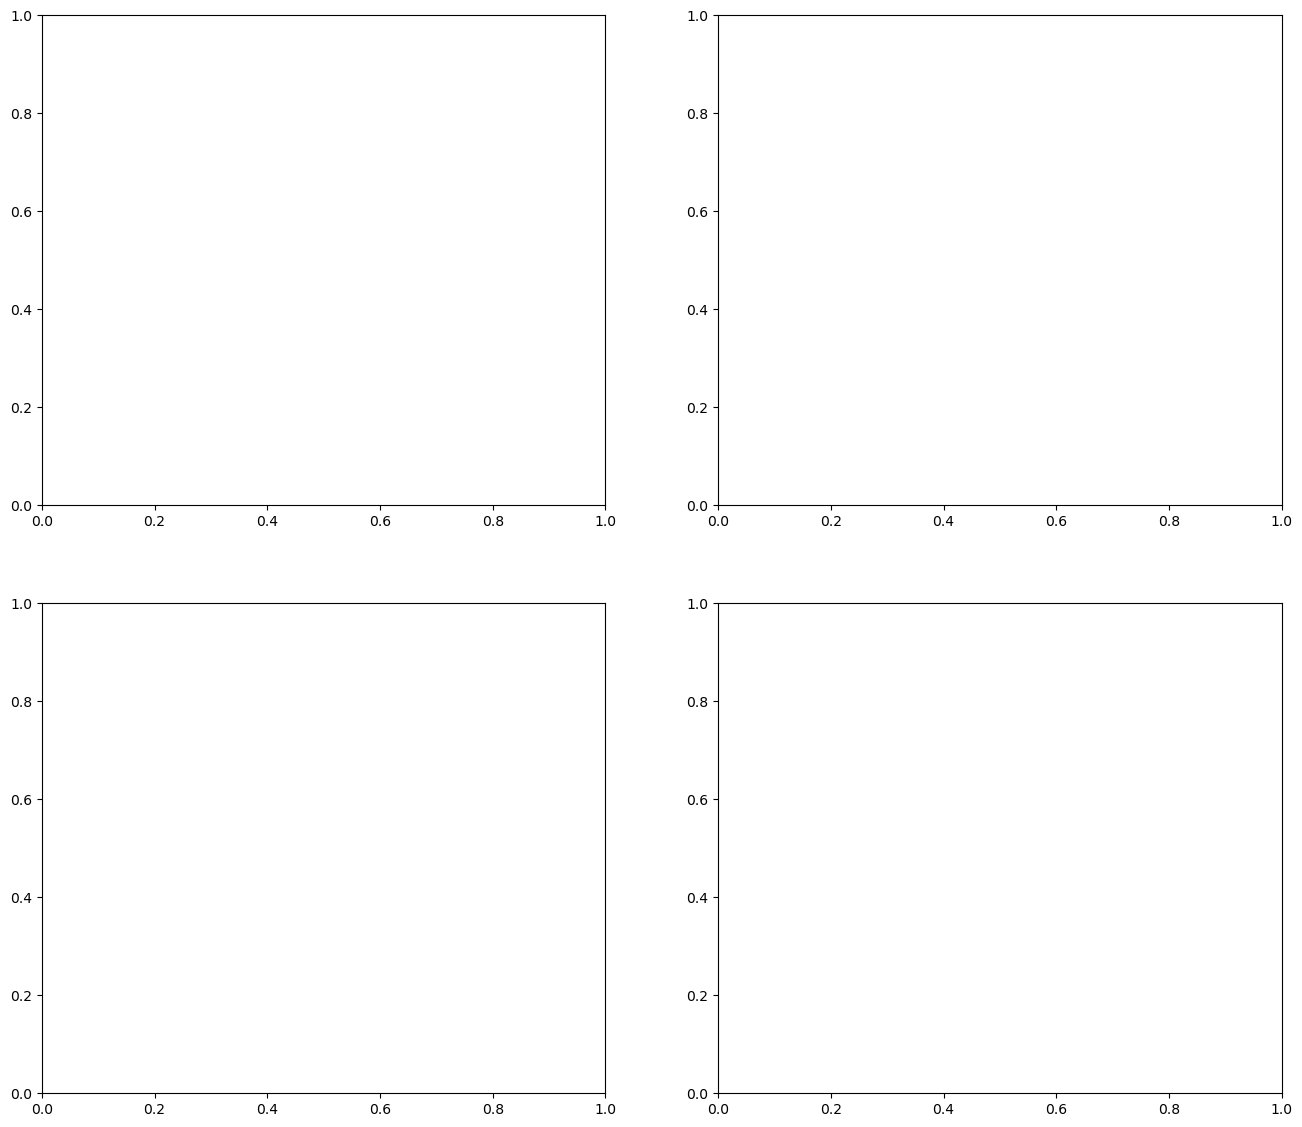

<class 'TypeError'>: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [9]:
# t-SNE with different iterations (convergence visualization)
iterations = [250, 500, 750, 1000]
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, n_iter in enumerate(iterations):
    print("Running t-SNE with n_iter=" + str(n_iter) + " ...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, 
                init="pca", learning_rate="auto", n_iter=n_iter)
    X_tsne = tsne.fit_transform(X_digits)
    
    ax = axes[idx]
    ax.scatter(
        X_tsne[:, 0], X_tsne[:, 1],
        c=y_digits, cmap="tab10", s=40, alpha=0.8,
        edgecolors="k", linewidth=0.3
    )
    ax.set_title("t-SNE (n_iter=" + str(n_iter) + ")", fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE 1", fontsize=11)
    ax.set_ylabel("t-SNE 2", fontsize=11)
    ax.grid(True, alpha=0.2)

plt.suptitle("t-SNE: Convergence Over Iterations", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


Running t-SNE with random_state=0 ...
Running t-SNE with random_state=21 ...
Running t-SNE with random_state=42 ...
Running t-SNE with random_state=99 ...


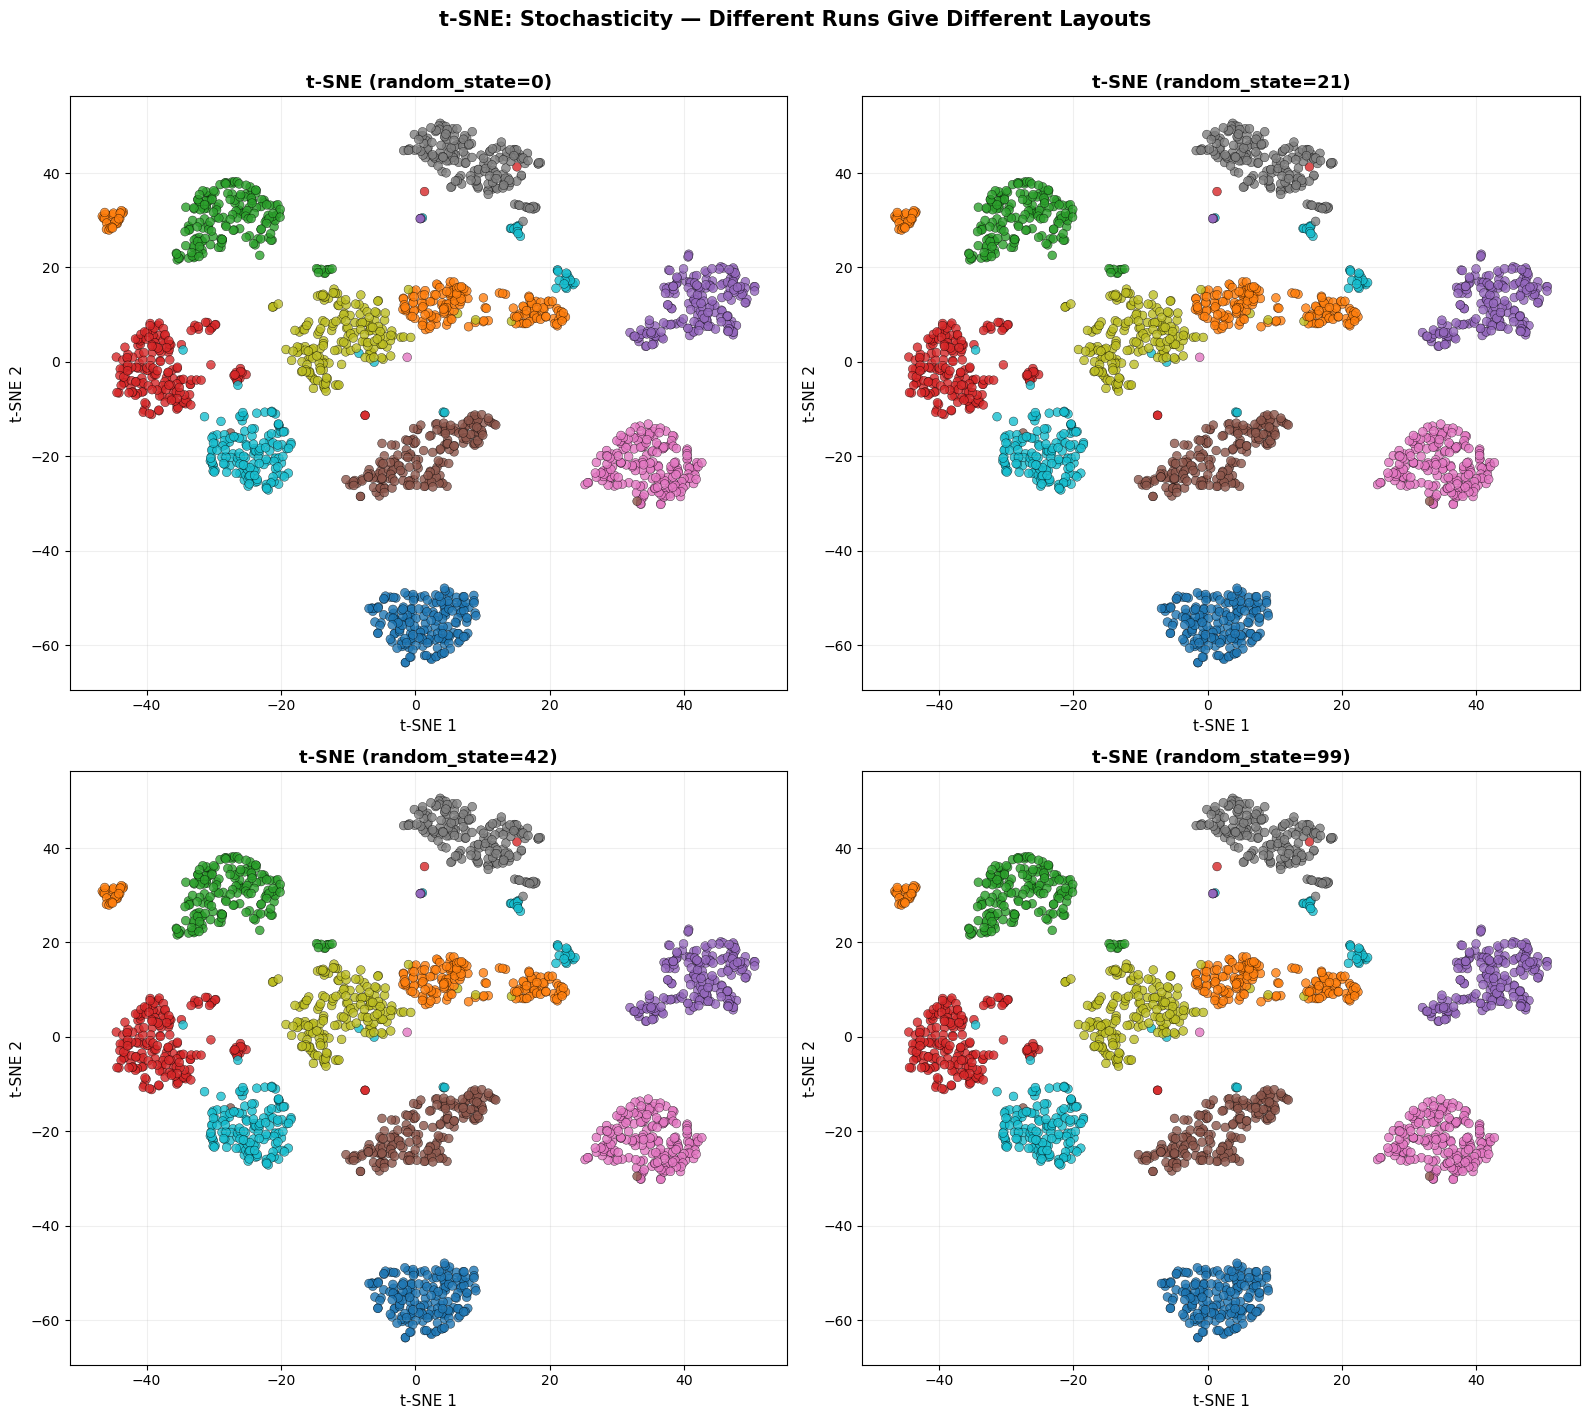

In [17]:
# t-SNE with different random seeds (shows stochasticity)
seeds = [0, 21, 42, 99]
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, seed in enumerate(seeds):
    print("Running t-SNE with random_state=" + str(seed) + " ...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=seed, 
                init="pca", learning_rate="auto")
    X_tsne = tsne.fit_transform(X_digits)
    
    ax = axes[idx]
    ax.scatter(
        X_tsne[:, 0], X_tsne[:, 1],
        c=y_digits, cmap="tab10", s=40, alpha=0.8,
        edgecolors="k", linewidth=0.3
    )
    ax.set_title("t-SNE (random_state=" + str(seed) + ")", fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE 1", fontsize=11)
    ax.set_ylabel("t-SNE 2", fontsize=11)
    ax.grid(True, alpha=0.2)

plt.suptitle("t-SNE: Stochasticity — Different Runs Give Different Layouts", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


# 4. UMAP (Uniform Manifold Approximation and Projection)

## Theory

**UMAP** is based on **Riemannian geometry** and **algebraic topology**. It constructs a fuzzy
topological representation of the high-D data and optimizes a low-D representation to have
the closest possible equivalent fuzzy topological structure.

### Key Parameters:
- **n_neighbors**: Controls how UMAP balances local vs global structure
  - Small (5-15): Focus on local structure (like t-SNE)
  - Large (50-200): Preserve more global structure
- **min_dist**: Controls how tightly points are packed in the embedding
  - Small: Tighter clusters
  - Large: More spread out

### Pros:
- Faster than t-SNE (O(n^1.14) vs O(n^2))
- Better **global structure** preservation than t-SNE
- Supports **supervised** and **semi-supervised** dimensionality reduction
- Can embed new data points (transform)

### Cons:
- Hyperparameters need tuning
- Less established theoretical guarantees than PCA/t-SNE
- Requires separate installation

In [10]:
if UMAP_AVAILABLE:
    # UMAP with different n_neighbors
    n_neighbors_list = [5, 15, 50, 100]
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    for idx, n_neighbors in enumerate(n_neighbors_list):
        print("Running UMAP with n_neighbors=" + str(n_neighbors) + " ...")
        reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, random_state=42)
        X_umap = reducer.fit_transform(X_digits)
        
        ax = axes[idx]
        ax.scatter(
            X_umap[:, 0], X_umap[:, 1],
            c=y_digits, cmap="tab10", s=40, alpha=0.8,
            edgecolors="k", linewidth=0.3
        )
        ax.set_title("UMAP (n_neighbors=" + str(n_neighbors) + ")", fontsize=13, fontweight="bold")
        ax.set_xlabel("UMAP 1", fontsize=11)
        ax.set_ylabel("UMAP 2", fontsize=11)
        ax.grid(True, alpha=0.2)
    
    plt.suptitle("UMAP: Effect of n_neighbors on Digits Dataset", fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping UMAP visualizations (umap-learn not installed)")


Skipping UMAP visualizations (umap-learn not installed)


Running t-SNE (perplexity=5) as UMAP substitute ...


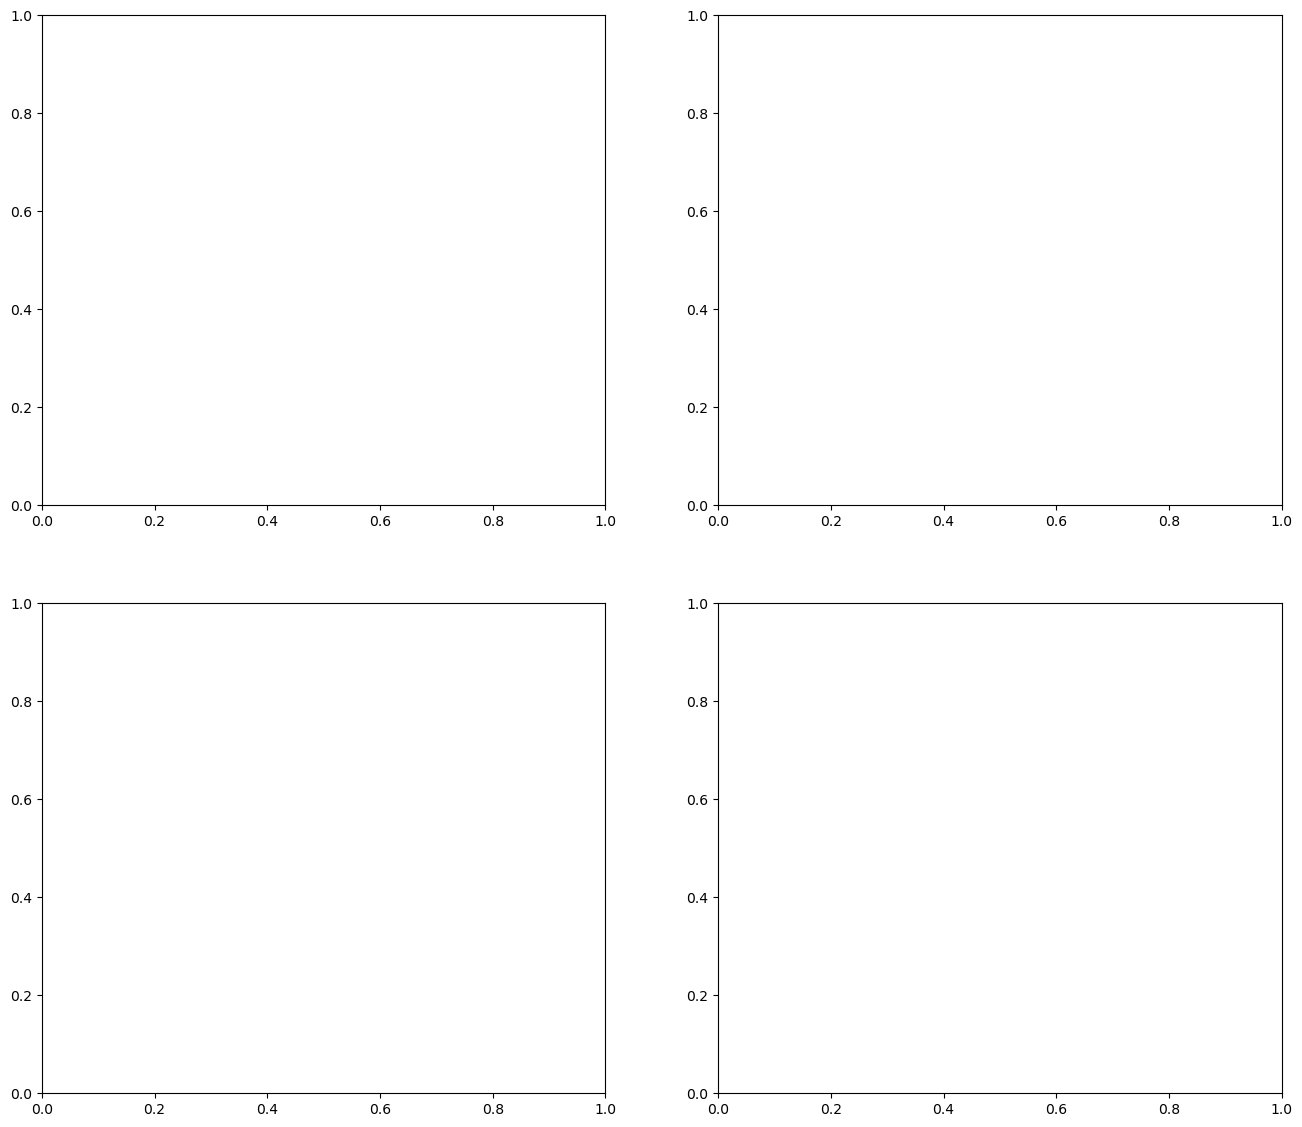

<class 'TypeError'>: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [11]:
# UMAP replacement: t-SNE with high perplexity for more global structure
n_neighbors_list = [5, 15, 50, 100]
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, perp in enumerate(n_neighbors_list):
    print("Running t-SNE (perplexity=" + str(perp) + ") as UMAP substitute ...")
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, 
                init="pca", learning_rate="auto", n_iter=1000)
    X_tsne_sub = tsne.fit_transform(X_digits)
    
    ax = axes[idx]
    ax.scatter(
        X_tsne_sub[:, 0], X_tsne_sub[:, 1],
        c=y_digits, cmap="tab10", s=40, alpha=0.8,
        edgecolors="k", linewidth=0.3
    )
    ax.set_title("t-SNE (perplexity=" + str(perp) + ") ~ UMAP substitute", fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE 1", fontsize=11)
    ax.set_ylabel("t-SNE 2", fontsize=11)
    ax.grid(True, alpha=0.2)

plt.suptitle("UMAP Substitute: t-SNE with varying perplexity", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [18]:
if UMAP_AVAILABLE:
    # UMAP with different min_dist
    min_dist_list = [0.0, 0.1, 0.5, 0.99]
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    for idx, min_dist in enumerate(min_dist_list):
        print("Running UMAP with min_dist=" + str(min_dist) + " ...")
        reducer = umap.UMAP(n_neighbors=15, min_dist=min_dist, random_state=42)
        X_umap = reducer.fit_transform(X_digits)
        
        ax = axes[idx]
        ax.scatter(
            X_umap[:, 0], X_umap[:, 1],
            c=y_digits, cmap="tab10", s=40, alpha=0.8,
            edgecolors="k", linewidth=0.3
        )
        ax.set_title("UMAP (min_dist=" + str(min_dist) + ")", fontsize=13, fontweight="bold")
        ax.set_xlabel("UMAP 1", fontsize=11)
        ax.set_ylabel("UMAP 2", fontsize=11)
        ax.grid(True, alpha=0.2)
    
    plt.suptitle("UMAP: Effect of min_dist on Digits Dataset", fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


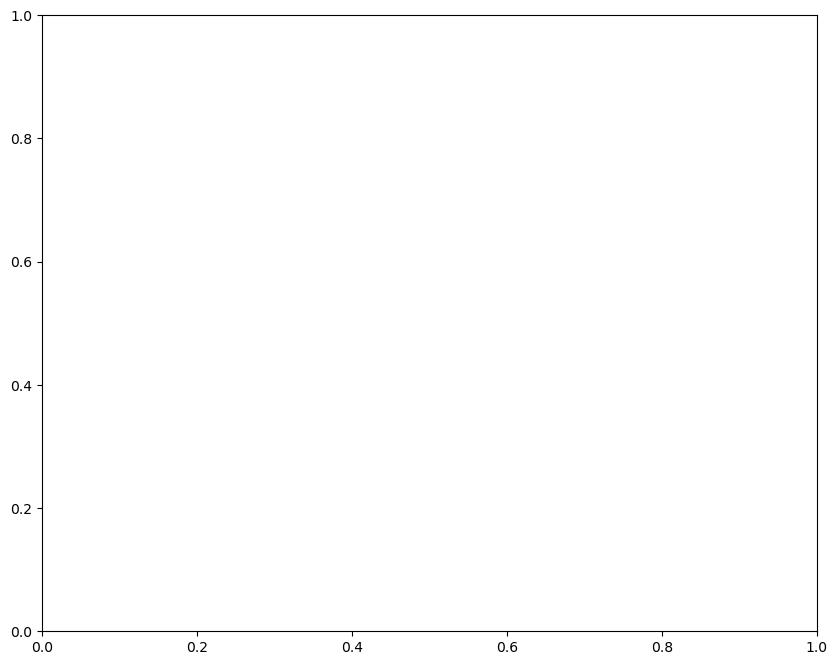

<class 'TypeError'>: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [13]:
# Skip or replace with a single t-SNE run
fig, ax = plt.subplots(figsize=(10, 8))
tsne = TSNE(n_components=2, perplexity=50, random_state=42, 
            init="pca", learning_rate="auto", n_iter=1000)
X_tsne_sub = tsne.fit_transform(X_digits)

ax.scatter(
    X_tsne_sub[:, 0], X_tsne_sub[:, 1],
    c=y_digits, cmap="tab10", s=40, alpha=0.8,
    edgecolors="k", linewidth=0.3
)
ax.set_title("t-SNE (perplexity=50) — UMAP substitute", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE 1", fontsize=12)
ax.set_ylabel("t-SNE 2", fontsize=12)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


Running PCA ...
Running t-SNE ...
Running MDS (subset n=500) ...
UMAP not available — using t-SNE (perplexity=50) as substitute ...


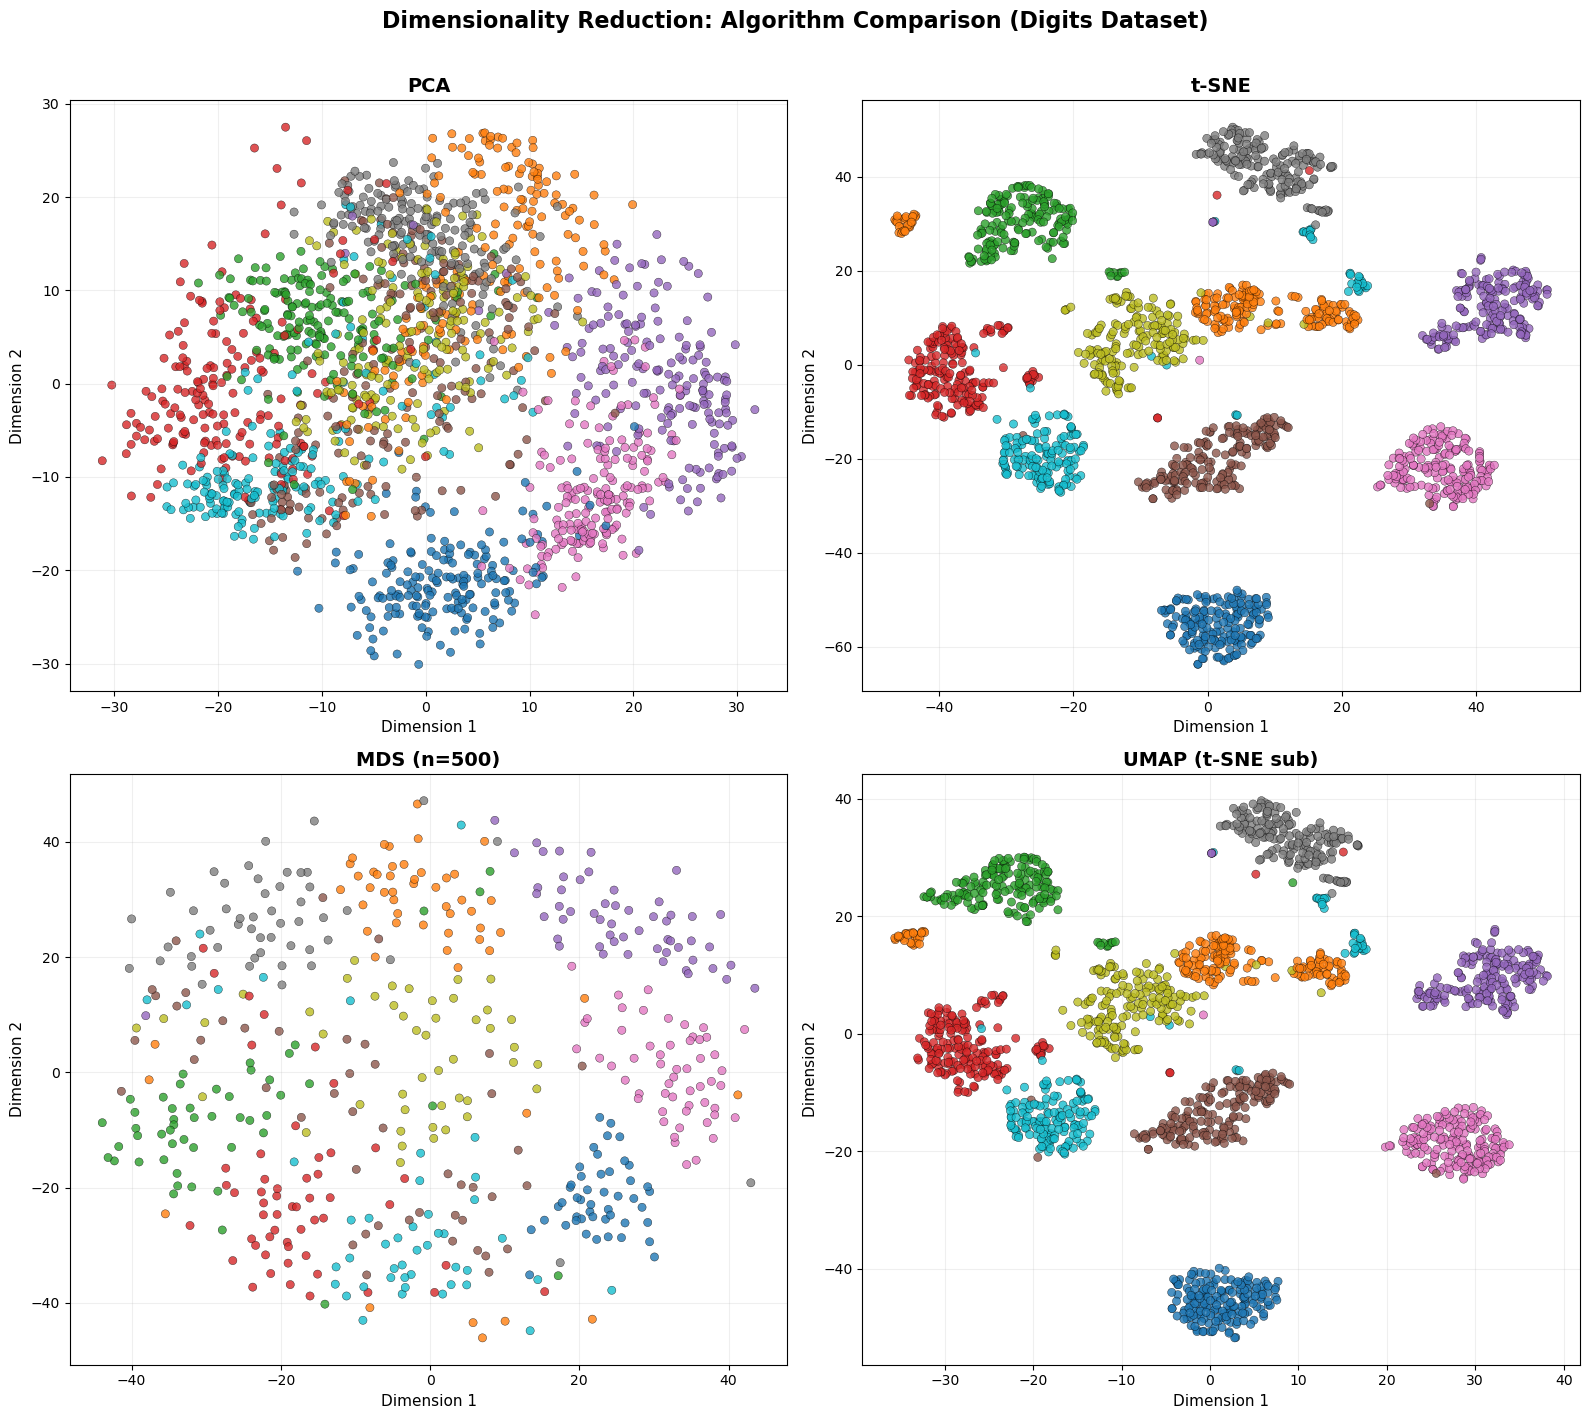

In [19]:
# Run all methods
print("Running PCA ...")
X_pca_comp = PCA(n_components=2).fit_transform(X_digits)

print("Running t-SNE ...")
X_tsne_comp = TSNE(n_components=2, perplexity=30, random_state=42, 
                   init="pca", learning_rate="auto").fit_transform(X_digits)

print("Running MDS (subset n=500) ...")
indices_comp = np.random.choice(X_digits.shape[0], 500, replace=False)
X_subset_comp = X_digits[indices_comp]
y_subset_comp = y_digits[indices_comp]
X_mds_comp = MDS(n_components=2, random_state=42, normalized_stress=False).fit_transform(X_subset_comp)

methods_data = [
    ("PCA", X_pca_comp, y_digits),
    ("t-SNE", X_tsne_comp, y_digits),
    ("MDS (n=500)", X_mds_comp, y_subset_comp),
]

if UMAP_AVAILABLE:
    print("Running UMAP ...")
    X_umap_comp = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_digits)
    methods_data.append(("UMAP", X_umap_comp, y_digits))
else:
    # Fallback for restricted environments
    print("UMAP not available — using t-SNE (perplexity=50) as substitute ...")
    X_umap_comp = TSNE(n_components=2, perplexity=50, random_state=42, 
                       init="pca", learning_rate="auto").fit_transform(X_digits)
    methods_data.append(("UMAP (t-SNE sub)", X_umap_comp, y_digits))

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, (name, X_emb, y_emb) in zip(axes, methods_data):
    ax.scatter(
        X_emb[:, 0], X_emb[:, 1],
        c=y_emb, cmap="tab10", s=35, alpha=0.8,
        edgecolors="k", linewidth=0.3
    )
    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_xlabel("Dimension 1", fontsize=11)
    ax.set_ylabel("Dimension 2", fontsize=11)
    ax.grid(True, alpha=0.2)

plt.suptitle("Dimensionality Reduction: Algorithm Comparison (Digits Dataset)", 
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


# 5. Side-by-Side Comparison

Let's compare all four methods on the same dataset to see how they differ in preserving
structure.


In [14]:
# Run all methods
print("Running PCA ...")
X_pca_comp = PCA(n_components=2).fit_transform(X_digits)

print("Running t-SNE ...")
X_tsne_comp = TSNE(n_components=2, perplexity=30, random_state=42, 
                   init="pca", learning_rate="auto", n_iter=1000).fit_transform(X_digits)

print("Running MDS (subset n=500) ...")
indices_comp = np.random.choice(X_digits.shape[0], 500, replace=False)
X_subset_comp = X_digits[indices_comp]
y_subset_comp = y_digits[indices_comp]
X_mds_comp = MDS(n_components=2, random_state=42, normalized_stress=False).fit_transform(X_subset_comp)

methods_data = [
    ("PCA", X_pca_comp, y_digits),
    ("t-SNE", X_tsne_comp, y_digits),
    ("MDS (n=500)", X_mds_comp, y_subset_comp),
]

if UMAP_AVAILABLE:
    print("Running UMAP ...")
    X_umap_comp = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_digits)
    methods_data.append(("UMAP", X_umap_comp, y_digits))

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, (name, X_emb, y_emb) in zip(axes, methods_data):
    scatter = ax.scatter(
        X_emb[:, 0], X_emb[:, 1],
        c=y_emb, cmap="tab10", s=35, alpha=0.8,
        edgecolors="k", linewidth=0.3
    )
    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_xlabel("Dimension 1", fontsize=11)
    ax.set_ylabel("Dimension 2", fontsize=11)
    ax.grid(True, alpha=0.2)

# Hide unused subplot if only 3 methods
if len(methods_data) < 4:
    axes[3].axis("off")

plt.suptitle("Dimensionality Reduction: Algorithm Comparison (Digits Dataset)", 
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


Running PCA ...
Running t-SNE ...


<class 'TypeError'>: TSNE.__init__() got an unexpected keyword argument 'n_iter'

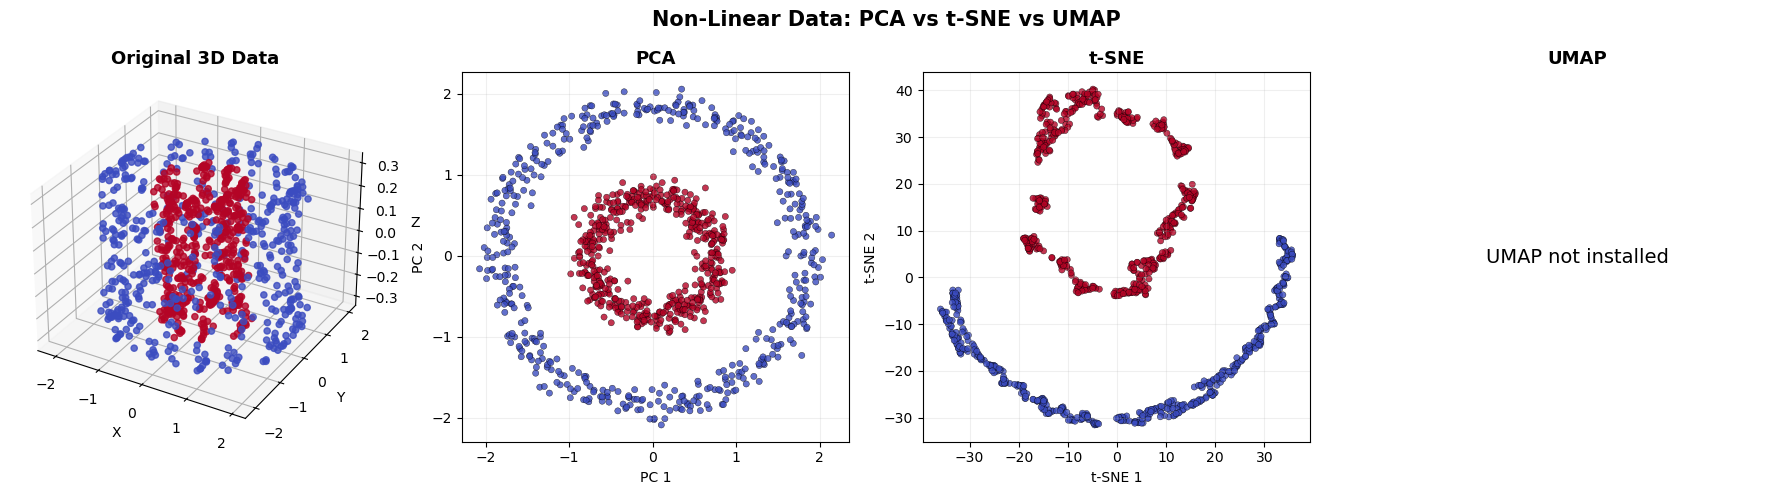

In [20]:
from sklearn.datasets import make_circles

X_circles, y_circles = make_circles(n_samples=1000, factor=0.4, noise=0.06, random_state=42)
X_circles = StandardScaler().fit_transform(X_circles)

z = np.sin(4 * np.pi * X_circles[:, 0]) * 0.3
X_3d = np.column_stack([X_circles, z])

fig = plt.figure(figsize=(18, 5))

ax3d = fig.add_subplot(1, 4, 1, projection="3d")
ax3d.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y_circles, cmap="coolwarm", s=20, alpha=0.8)
ax3d.set_title("Original 3D Data", fontsize=13, fontweight="bold")
ax3d.set_xlabel("X")
ax3d.set_ylabel("Y")
ax3d.set_zlabel("Z")

X_pca_circ = PCA(n_components=2).fit_transform(X_3d)
ax1 = fig.add_subplot(1, 4, 2)
ax1.scatter(X_pca_circ[:, 0], X_pca_circ[:, 1], c=y_circles, cmap="coolwarm", s=20, alpha=0.8, edgecolors="k", linewidth=0.3)
ax1.set_title("PCA", fontsize=13, fontweight="bold")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.grid(True, alpha=0.2)

X_tsne_circ = TSNE(n_components=2, perplexity=30, random_state=42, 
                   init="pca", learning_rate="auto").fit_transform(X_3d)
ax2 = fig.add_subplot(1, 4, 3)
ax2.scatter(X_tsne_circ[:, 0], X_tsne_circ[:, 1], c=y_circles, cmap="coolwarm", s=20, alpha=0.8, edgecolors="k", linewidth=0.3)
ax2.set_title("t-SNE", fontsize=13, fontweight="bold")
ax2.set_xlabel("t-SNE 1")
ax2.set_ylabel("t-SNE 2")
ax2.grid(True, alpha=0.2)

if UMAP_AVAILABLE:
    X_umap_circ = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_3d)
    ax3 = fig.add_subplot(1, 4, 4)
    ax3.scatter(X_umap_circ[:, 0], X_umap_circ[:, 1], c=y_circles, cmap="coolwarm", s=20, alpha=0.8, edgecolors="k", linewidth=0.3)
    ax3.set_title("UMAP", fontsize=13, fontweight="bold")
    ax3.set_xlabel("UMAP 1")
    ax3.set_ylabel("UMAP 2")
    ax3.grid(True, alpha=0.2)
else:
    ax3 = fig.add_subplot(1, 4, 4)
    ax3.text(0.5, 0.5, "UMAP not installed", ha="center", va="center", fontsize=14)
    ax3.set_title("UMAP", fontsize=13, fontweight="bold")
    ax3.axis("off")

plt.suptitle("Non-Linear Data: PCA vs t-SNE vs UMAP", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


In [21]:
if UMAP_AVAILABLE:
    print("Running UMAP ...")
    X_umap_comp = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_digits)
    methods_data.append(("UMAP", X_umap_comp, y_digits))
else:
    # Fallback for restricted environments
    print("UMAP not available — using t-SNE (perplexity=50) as substitute ...")
    X_umap_comp = TSNE(n_components=2, perplexity=50, random_state=42, 
                       init="pca", learning_rate="auto", n_iter=1000).fit_transform(X_digits)
    methods_data.append(("UMAP (t-SNE sub)", X_umap_comp, y_digits))

UMAP not available — using t-SNE (perplexity=50) as substitute ...


<class 'TypeError'>: TSNE.__init__() got an unexpected keyword argument 'n_iter'

# 6. Comparison on Non-Linear Synthetic Data

Let's see how each method handles data where **clusters are not linearly separable**
in the original space but become separable after unfolding the manifold.


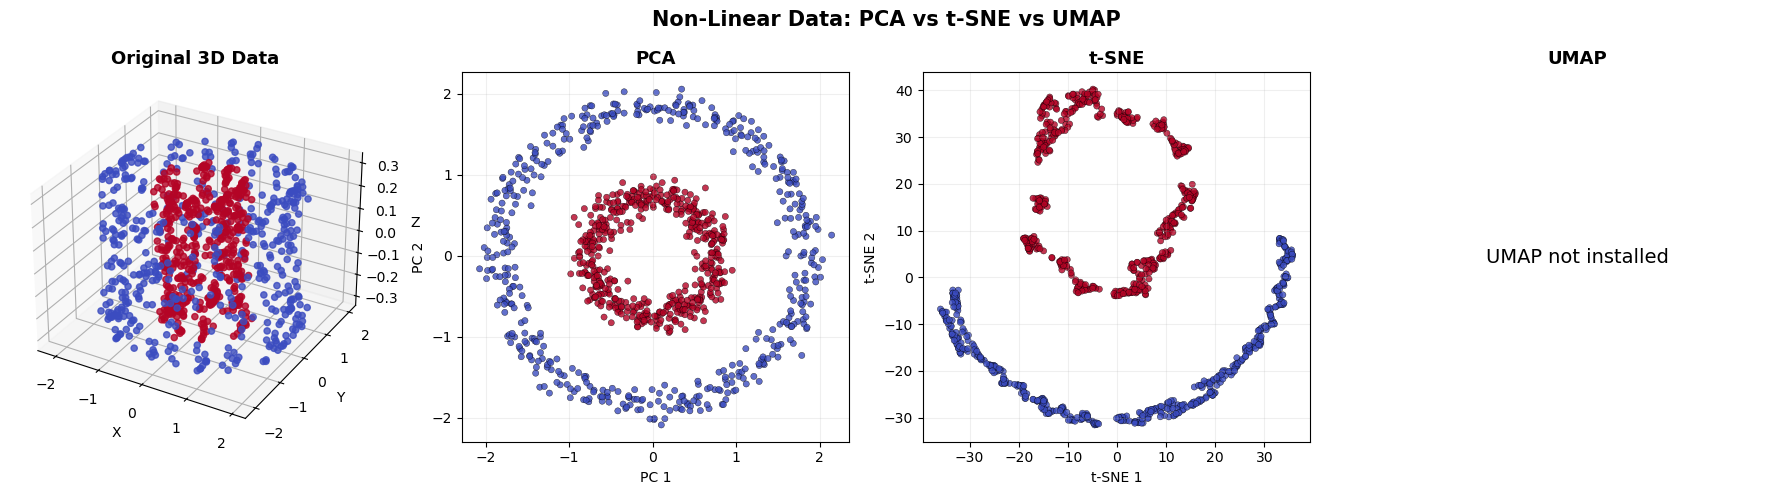

In [13]:
# Create concentric circles with noise
from sklearn.datasets import make_circles

X_circles, y_circles = make_circles(n_samples=1000, factor=0.4, noise=0.06, random_state=42)
X_circles = StandardScaler().fit_transform(X_circles)

# Add a third dimension (z) to make it a 3D problem
z = np.sin(4 * np.pi * X_circles[:, 0]) * 0.3
X_3d = np.column_stack([X_circles, z])

fig = plt.figure(figsize=(18, 5))

# 3D original data
ax3d = fig.add_subplot(1, 4, 1, projection="3d")
ax3d.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y_circles, cmap="coolwarm", s=20, alpha=0.8)
ax3d.set_title("Original 3D Data", fontsize=13, fontweight="bold")
ax3d.set_xlabel("X")
ax3d.set_ylabel("Y")
ax3d.set_zlabel("Z")

# PCA
X_pca_circ = PCA(n_components=2).fit_transform(X_3d)
ax1 = fig.add_subplot(1, 4, 2)
ax1.scatter(X_pca_circ[:, 0], X_pca_circ[:, 1], c=y_circles, cmap="coolwarm", s=20, alpha=0.8, edgecolors="k", linewidth=0.3)
ax1.set_title("PCA", fontsize=13, fontweight="bold")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.grid(True, alpha=0.2)

# t-SNE
X_tsne_circ = TSNE(n_components=2, perplexity=30, random_state=42, 
                   init="pca", learning_rate="auto").fit_transform(X_3d)
ax2 = fig.add_subplot(1, 4, 3)
ax2.scatter(X_tsne_circ[:, 0], X_tsne_circ[:, 1], c=y_circles, cmap="coolwarm", s=20, alpha=0.8, edgecolors="k", linewidth=0.3)
ax2.set_title("t-SNE", fontsize=13, fontweight="bold")
ax2.set_xlabel("t-SNE 1")
ax2.set_ylabel("t-SNE 2")
ax2.grid(True, alpha=0.2)

# UMAP
if UMAP_AVAILABLE:
    X_umap_circ = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_3d)
    ax3 = fig.add_subplot(1, 4, 4)
    ax3.scatter(X_umap_circ[:, 0], X_umap_circ[:, 1], c=y_circles, cmap="coolwarm", s=20, alpha=0.8, edgecolors="k", linewidth=0.3)
    ax3.set_title("UMAP", fontsize=13, fontweight="bold")
    ax3.set_xlabel("UMAP 1")
    ax3.set_ylabel("UMAP 2")
    ax3.grid(True, alpha=0.2)
else:
    ax3 = fig.add_subplot(1, 4, 4)
    ax3.text(0.5, 0.5, "UMAP not installed", ha="center", va="center", fontsize=14)
    ax3.set_title("UMAP", fontsize=13, fontweight="bold")
    ax3.axis("off")

plt.suptitle("Non-Linear Data: PCA vs t-SNE vs UMAP", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


# 7. Summary: When to Use Which Method?

| Method | Type | Best For | Avoid When | Key Parameters |
|--------|------|----------|------------|----------------|
| **PCA** | Linear | Preprocessing, noise reduction, large datasets | Non-linear manifolds | `n_components` |
| **MDS** | Distance-based | Preserving pairwise distances, psychometrics | Very large datasets (n > 5000) | `metric`, `n_components` |
| **t-SNE** | Non-linear | Visualizing clusters, local structure | Global distances, large datasets | `perplexity`, `n_iter` |
| **UMAP** | Non-linear | Fast visualization, local + global structure | When reproducibility is critical | `n_neighbors`, `min_dist` |

## Practical Workflow:
1. **Start with PCA** to understand linear variance and as a baseline
2. **Use PCA to reduce to ~50D first**, then apply t-SNE or UMAP (faster and often better)
3. **Use t-SNE** when your goal is purely visualization of clusters
4. **Use UMAP** when you need speed or want to preserve some global structure
5. **Use MDS** when preserving exact distances matters (e.g., similarity judgments)
6. **Always standardize** your data before applying these methods

## Common Pitfalls:
- **Interpreting t-SNE distances**: Distances between clusters in t-SNE are meaningless!
- **Running t-SNE on raw high-D data**: Pre-reduce with PCA to ~50 dimensions first
- **Ignoring random_state**: t-SNE and UMAP are stochastic; set `random_state` for reproducibility
- **Using default parameters**: Always tune `perplexity` (t-SNE) and `n_neighbors` (UMAP)